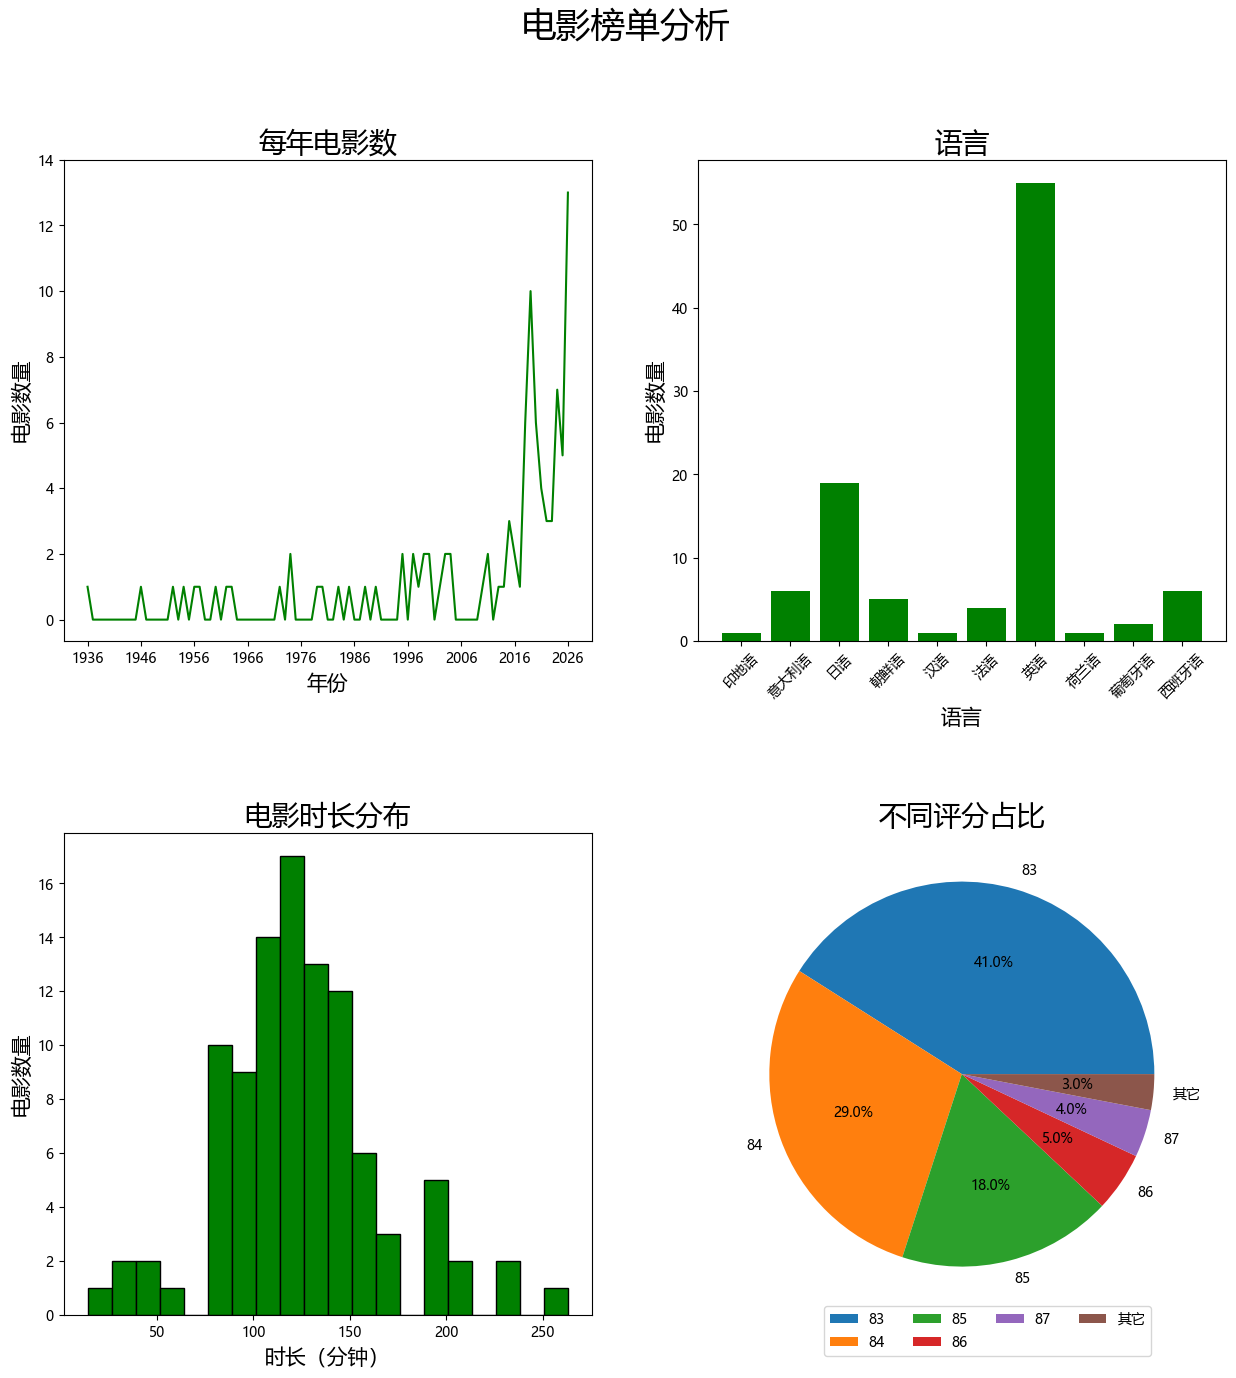

In [30]:
from matplotlib.axes import Axes
from matplotlib import pyplot as plt
import pandas as pd
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']

fig,axes = plt.subplots(nrows=2,ncols=2,figsize=(15,15),dpi=100)
fig.suptitle('电影榜单分析',fontsize=25)
fig.subplots_adjust(hspace=0.4, wspace=0.2)

axes1:Axes = axes[0][0]
axes2:Axes = axes[0][1]
axes3:Axes = axes[1][0]
axes4:Axes = axes[1][1]

data = pd.read_csv('data/movies.csv',usecols=['电影名','上映时间','时长','评分','语言'])

# 图一：统计电影发布年份
# 提取发布年份，并转换成int类型
data['年份'] = data['上映时间'].str[:4].astype(int)

year_count = data.groupby('年份')['年份'].count()

min_year = year_count.index.min()
max_year = year_count.index.max()
x1 = [i for i in range(min_year,max_year+1)]
y1 = [int(year_count.get(i,0)) for i in x1]

axes1.plot(x1,y1,color='green')
axes1.set_title('每年电影数',fontsize=20)
axes1.set_xlabel('年份',fontsize=15)
axes1.set_ylabel('电影数量',fontsize=15)
axes1.set_xticks(x1[::10])
axes1.set_yticks([i for i in range(0,15,2)])

# 图二：统计电影语言
language_count = data.groupby('语言')['语言'].count()
x2 = language_count.index.tolist()
y2 = language_count.values.tolist()

axes2.bar(x2,y2,color='green')
axes2.set_title('语言',fontsize=20)
axes2.set_xlabel('语言',fontsize=15)
axes2.set_ylabel('电影数量',fontsize=15)
axes2.tick_params(axis='x', rotation=45)

# 图三：统计电影时长分布（直方图）
duration_data = data['时长']

axes3.hist(duration_data, bins=20, color='green', edgecolor='black')
axes3.set_title('电影时长分布', fontsize=20)
axes3.set_xlabel('时长（分钟）', fontsize=15)
axes3.set_ylabel('电影数量', fontsize=15)

# 图四：统计不同电影评分
score_count = data.groupby('评分')['评分'].count()
total = score_count.sum()
large_scores = score_count.loc[score_count > total*0.02]
small_scores = score_count.loc[score_count <= total*0.02]
if small_scores.shape[0]>0:
    large_scores['其它'] = small_scores.sum()

x4 = large_scores.index.tolist()
y4 = large_scores.values.tolist()

axes4.pie(y4, labels=x4, autopct='%1.1f%%')
axes4.set_title('不同评分占比',fontsize=20)
axes4.legend(loc='lower left',ncol=4,fontsize=10,bbox_to_anchor=(0.2,-0.1))


plt.savefig('data/TOP100.png')
plt.show()